# **Diplomado IA: Inteligencia Artificial II - Métodos de Profundización**. <br> Práctico: Meta Aprendizaje (Parte 1)
---
---

**Profesor:** Pablo Messina (pamessina@uc.cl)


# Introducción

Este laboratorio está basado fuertemente en [learn2learn](https://learn2learn.net/examples/vision/), una librería open-source para investigación en meta-learning.

En particular, veremos el uso de dos métodos concretos:

1) Model-Agnostic Meta-Learning (MAML): https://arxiv.org/abs/1703.03400

2) Prototypical Networks for Few-shot Learning: https://arxiv.org/abs/1703.05175

Los datasets que usaremos son Omniglot y Mini-ImageNet, y los códigos consultados para la confección de este laboratorio son los siguientes:

- https://github.com/learnables/learn2learn/blob/master/examples/vision/maml_omniglot.py
- https://github.com/learnables/learn2learn/blob/master/examples/vision/maml_miniimagenet.py
- https://github.com/learnables/learn2learn/blob/master/examples/vision/protonet_miniimagenet.py


# Instalando e importando librerías a usar

Instalamos learn2learn desde GitHub primero debido al siguiente issue: https://github.com/learnables/learn2learn/issues/433

In [1]:
!git clone https://github.com/learnables/learn2learn.git
%cd learn2learn
!pip install -e .

fatal: destination path 'learn2learn' already exists and is not an empty directory.
/content/learn2learn
Obtaining file:///content/learn2learn
  Preparing metadata (setup.py) ... done
  Attempting uninstall: learn2learn
    Found existing installation: learn2learn 0.2.1
    Uninstalling learn2learn-0.2.1:
      Successfully uninstalled learn2learn-0.2.1
  Running setup.py develop for learn2learn


Luego Colab debería pedirles reiniciar el entorno de ejecución. Reinician, e immediatamente después instalan learn2learn con el comando típico !pip install learn2learn:

In [2]:
!pip install learn2learn

Importamos librerías a usar

In [3]:
import gc
import random
import numpy as np
import learn2learn as l2l
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch import nn, optim
from typing import List, Tuple
from IPython.display import clear_output

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

Usamos cuda

In [4]:
use_cuda = torch.cuda.is_available() and True
device = torch.device("cuda" if use_cuda else "cpu")
device

device(type='cuda')

# Cargamos datasets: Omniglot y Mini-ImageNet

Funciones para visualizar tareas de ambos datasets

In [5]:
def visualize_task_omniglot(
    batch: Tuple[torch.Tensor, torch.Tensor], shot: int, ways: int
) -> None:
    """
    Visualize a sampled Omniglot task by splitting into adaptation and evaluation sets.

    Args:
        batch: A tuple (data, labels) where
            - data: Tensor of shape (N, 1, H, W), grayscale Omniglot images.
            - labels: Tensor of shape (N,), class labels (not used here).
        shot: Number of examples per class for adaptation.
        ways: Number of classes per task.

    Returns:
        None. Displays matplotlib figures with adaptation and evaluation images.
    """
    data = batch[0]

    # Create boolean masks for adaptation and evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shot * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    # Split data into adaptation and evaluation sets
    adaptation_data = data[adaptation_indices]
    evaluation_data = data[evaluation_indices]

    # --- Plot adaptation data ---
    print("Adaptation data:")
    n = len(adaptation_data)
    f, axarr = plt.subplots(1, n, figsize=(10, 10))
    for i in range(n):
        axarr[i].imshow(adaptation_data[i, 0], cmap="gray")
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

    # --- Plot evaluation data ---
    print("Evaluation data:")
    n = len(evaluation_data)
    f, axarr = plt.subplots(1, n, figsize=(10, 10))
    for i in range(n):
        axarr[i].imshow(evaluation_data[i, 0], cmap="gray")
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()


def visualize_task_miniimagenet(
    batch: Tuple[torch.Tensor, torch.Tensor], shots: int, ways: int
) -> None:
    """
    Visualize a sampled Mini-ImageNet task by splitting into adaptation and evaluation sets.

    Args:
        batch: A tuple (data, labels) where
            - data: Tensor of shape (N, 3, H, W), RGB Mini-ImageNet images.
            - labels: Tensor of shape (N,), class labels (not used here).
        shots: Number of examples per class for adaptation.
        ways: Number of classes per task.

    Returns:
        None. Displays matplotlib figures with adaptation and evaluation images.
    """
    data = batch[0]

    # Create boolean masks for adaptation and evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shots * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    # Split data into adaptation and evaluation sets
    adaptation_data = data[adaptation_indices]
    evaluation_data = data[evaluation_indices]

    # --- Plot adaptation data ---
    print("Adaptation data:")
    n = len(adaptation_data)
    f, axarr = plt.subplots(1, n, figsize=(15, 15))
    for i in range(n):
        # Permute channels to (H, W, C) and normalize to [0, 1]
        axarr[i].imshow(adaptation_data[i].permute(1, 2, 0) / 255.0)
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

    # --- Plot evaluation data ---
    print("Evaluation data:")
    n = len(evaluation_data)
    f, axarr = plt.subplots(1, n, figsize=(15, 15))
    for i in range(n):
        axarr[i].imshow(evaluation_data[i].permute(1, 2, 0) / 255.0)
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

Definimos WAYS y SHOTS que usaremos

In [6]:
WAYS = 4
SHOTS = 1

## Cargamos e inspeccionamos Omniglot

In [7]:
tasksets_omniglot = l2l.vision.benchmarks.get_tasksets('omniglot',
                                                       train_ways=WAYS,
                                                       train_samples=2*SHOTS,
                                                       test_ways=WAYS,
                                                       test_samples=2*SHOTS,
                                                       num_tasks=10000,
                                                       root='~/data',
)

100%|██████████| 9.46M/9.46M [00:00<00:00, 66.4MB/s]
100%|██████████| 6.46M/6.46M [00:00<00:00, 85.4MB/s]


Adaptation data:


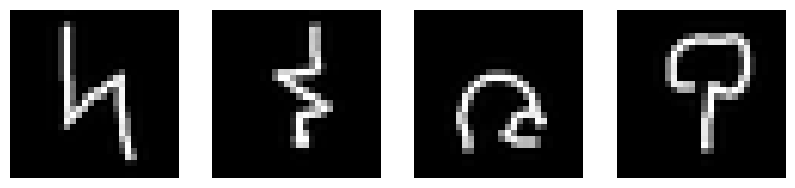

Evaluation data:


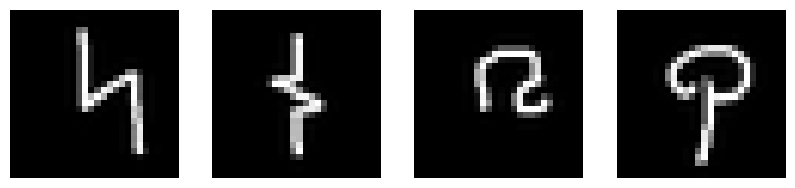

In [8]:
visualize_task_omniglot(tasksets_omniglot.train.sample(), SHOTS, WAYS)

Adaptation data:


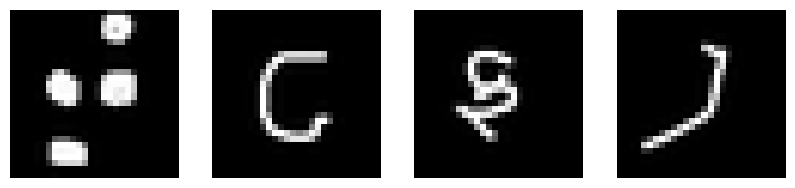

Evaluation data:


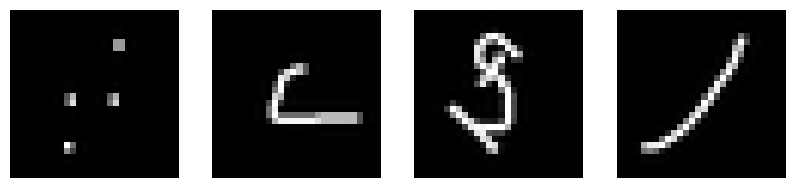

In [9]:
visualize_task_omniglot(tasksets_omniglot.validation.sample(), SHOTS, WAYS)

Adaptation data:


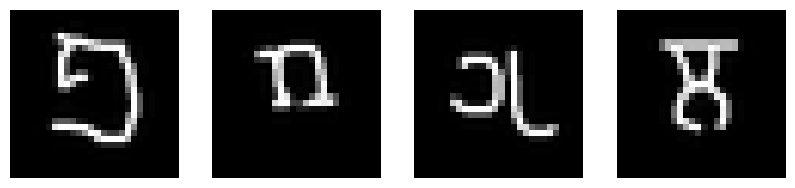

Evaluation data:


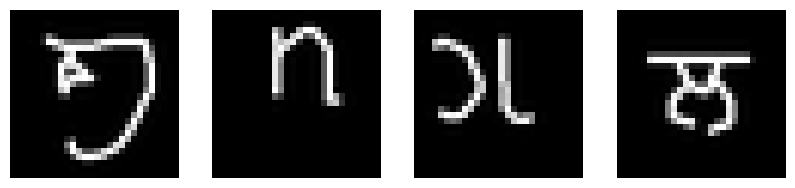

In [10]:
visualize_task_omniglot(tasksets_omniglot.test.sample(), SHOTS, WAYS)

## Cargamos e inspeccionamos Mini-ImageNet

In [11]:
# Si la descarga de archivos falla, los siguientes comandos se pueden correr para descargar los archivos manualmente
# !wget -O ~/data/mini-imagenet-cache-validation.pkl https://www.dropbox.com/s/ip1b7se3gij3r1b/mini-imagenet-cache-validation.pkl?dl=1
# !wget -O ~/data/mini-imagenet-cache-train.pkl https://www.dropbox.com/s/9g8c6w345s2ek03/mini-imagenet-cache-train.pkl?dl=1
# !wget -O ~/data/mini-imagenet-cache-test.pkl https://www.dropbox.com/s/ye9jeb5tyz0x01b/mini-imagenet-cache-test.pkl?dl=1

In [11]:
tasksets_miniimagenet = l2l.vision.benchmarks.get_tasksets('mini-imagenet',
                                                           train_ways=WAYS,
                                                           train_samples=2*SHOTS,
                                                           test_ways=WAYS,
                                                           test_samples=2*SHOTS,
                                                           num_tasks=10000,
                                                           root='~/data',
)

Adaptation data:


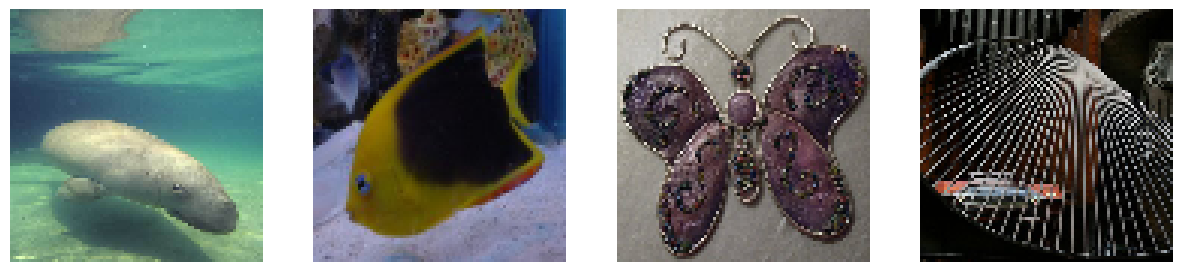

Evaluation data:


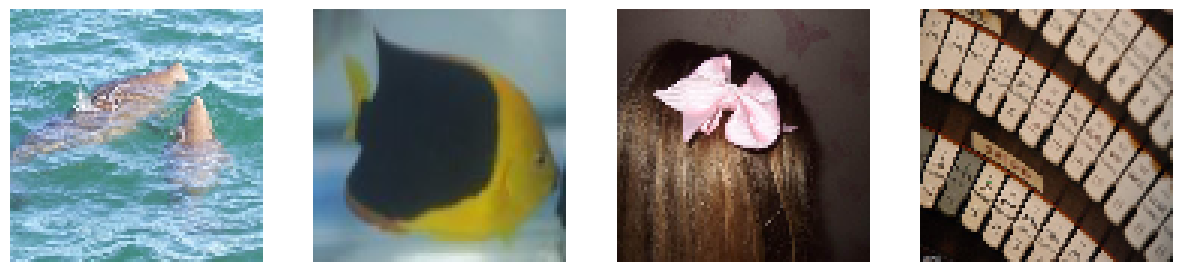

In [12]:
visualize_task_miniimagenet(tasksets_miniimagenet.train.sample(), SHOTS, WAYS)

Adaptation data:


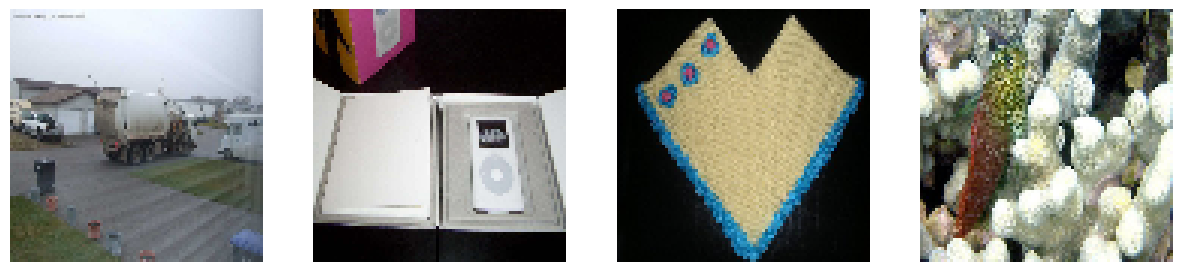

Evaluation data:


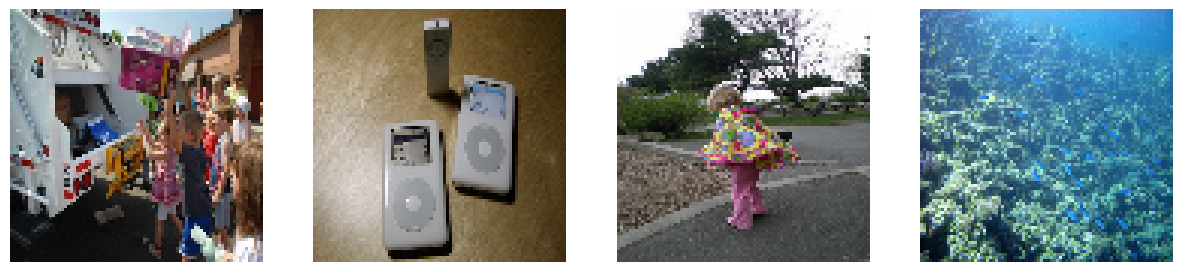

In [13]:
visualize_task_miniimagenet(tasksets_miniimagenet.validation.sample(), SHOTS, WAYS)

Adaptation data:


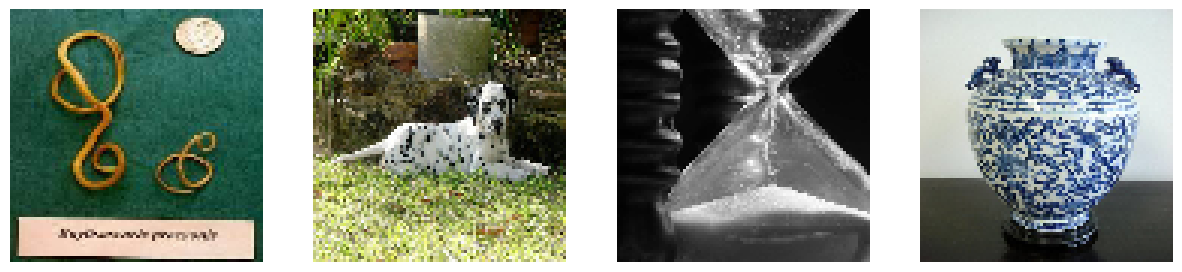

Evaluation data:


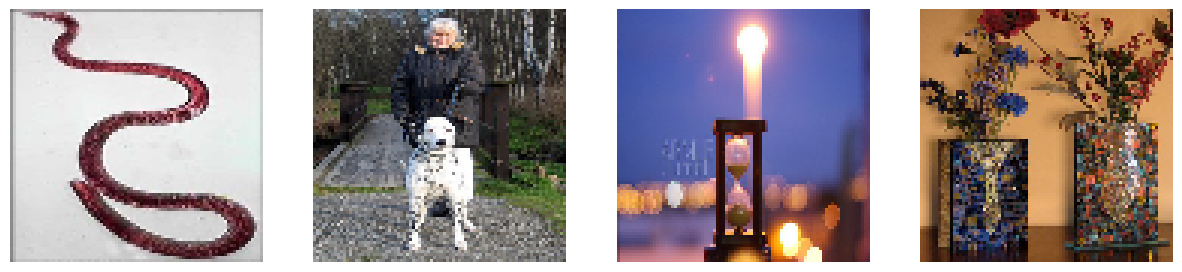

In [14]:
visualize_task_miniimagenet(tasksets_miniimagenet.test.sample(), SHOTS, WAYS)

**IMPORTANTE**: Borramos tasksets y corremos garbage collection para ahorrar RAM (pueden ver el impacto a la derecha si abren el monitor de recursos)

In [15]:
del tasksets_omniglot, tasksets_miniimagenet
gc.collect()

35044

# Algunas funciones de utilidad

In [16]:
def plot_train_valid_curves(
    train_error: List[float],
    train_acc: List[float],
    valid_error: List[float],
    valid_acc: List[float],
    figsize: Tuple[int, int] = (10, 6),
) -> None:
    """
    Plot training and validation error/accuracy curves per epoch.

    Args:
        train_error: List of training error values per epoch.
        train_acc: List of training accuracy values per epoch.
        valid_error: List of validation error values per epoch.
        valid_acc: List of validation accuracy values per epoch.
        figsize: Tuple specifying the figure size (width, height).

    Returns:
        None. Displays the plots using matplotlib.
    """
    plt.figure(figsize=figsize)
    epochs = list(range(1, len(train_error) + 1))

    # Plot error curves
    plt.subplot(121)
    plt.title("Error per epoch")
    plt.plot(epochs, train_error, label="train_error")
    plt.plot(epochs, valid_error, label="valid_error")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()

    # Plot accuracy curves
    plt.subplot(122)
    plt.title("Accuracy per epoch")
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, valid_acc, label="valid_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()


def accuracy(predictions: torch.Tensor, targets: torch.Tensor) -> float:
    """
    Compute classification accuracy.

    Args:
        predictions: Model output logits of shape (batch_size, num_classes).
        targets: Ground-truth labels of shape (batch_size,).

    Returns:
        Accuracy as a float in the range [0, 1].
    """
    predicted_labels = predictions.argmax(dim=1).view(targets.shape)
    correct = (predicted_labels == targets).sum().float()
    return (correct / targets.size(0))

# Model-Agnostic Meta-Learning (MAML)

In [17]:
def fast_adapt_MAML(
    batch: Tuple[torch.Tensor, torch.Tensor],
    learner: l2l.algorithms.MAML,
    loss: nn.Module,
    adaptation_steps: int,
    shots: int,
    ways: int,
    device: torch.device,
) -> Tuple[torch.Tensor, float]:
    """
    Perform fast adaptation for a single task in MAML.

    Args:
        batch: A tuple of (data, labels) sampled from the taskset.
        learner: A cloned model from the MAML meta-learner.
        loss: Loss function (e.g., CrossEntropyLoss).
        adaptation_steps: Number of inner-loop adaptation steps.
        shots: Number of examples per class for adaptation.
        ways: Number of classes per task.
        device: Torch device (CPU or CUDA).

    Returns:
        valid_error: Loss on the evaluation set.
        valid_accuracy: Accuracy on the evaluation set.
    """
    data, labels = batch
    data, labels = data.to(device), labels.to(device)

    # Separate data into adaptation/evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shots * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    adaptation_data, adaptation_labels = (
        data[adaptation_indices],
        labels[adaptation_indices],
    )
    evaluation_data, evaluation_labels = (
        data[evaluation_indices],
        labels[evaluation_indices],
    )

    # Adapt the model
    for step in range(adaptation_steps):
        train_error = loss(learner(adaptation_data), adaptation_labels)
        train_error /= len(adaptation_data)
        learner.adapt(train_error)

    # Evaluate the adapted model
    predictions = learner(evaluation_data)
    valid_error = loss(predictions, evaluation_labels)
    valid_error /= len(evaluation_data)
    valid_accuracy = accuracy(predictions, evaluation_labels)

    return valid_error, valid_accuracy


def run_MAML(
    dataset: str,
    model: nn.Module,
    device: torch.device,
    ways: int = 5,
    shots: int = 1,
    meta_lr: float = 0.003,
    fast_lr: float = 0.5,
    meta_batch_size: int = 32,
    adaptation_steps: int = 1,
    num_iterations: int = 100,
    cuda: bool = True,
    seed: int = 42,
    root: str = "~/data",
) -> None:
    """
    Run the MAML meta-learning algorithm on Omniglot or Mini-ImageNet.

    Args:
        dataset: Either 'omniglot' or 'mini-imagenet'.
        model: The base model to meta-learn.
        device: Torch device (CPU or CUDA).
        ways: Number of classes per task.
        shots: Number of examples per class for adaptation.
        meta_lr: Learning rate for the meta-optimizer.
        fast_lr: Learning rate for the inner-loop adaptation.
        meta_batch_size: Number of tasks per meta-batch.
        adaptation_steps: Number of inner-loop adaptation steps.
        num_iterations: Number of meta-training iterations.
        cuda: Whether to use CUDA.
        seed: Random seed for reproducibility.
        root: Path to dataset storage.

    Returns:
        None. Prints training/validation/test metrics and plots curves.
    """
    # Validate dataset choice
    if dataset not in ["omniglot", "mini-imagenet"]:
        raise ValueError("Dataset must be either 'omniglot' or 'mini-imagenet'.")

    # Set seeds
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if cuda:
        torch.cuda.manual_seed(seed)

    # Construct tasksets inside the function
    tasksets = l2l.vision.benchmarks.get_tasksets(
        dataset,
        train_ways=ways,
        train_samples=2 * shots,
        test_ways=ways,
        test_samples=2 * shots,
        num_tasks=10000,  # reduce if Colab runs out of memory
        root=root,
    )

    # MAML
    maml = l2l.algorithms.MAML(model, lr=fast_lr, first_order=True)

    # Optimizer
    opt = optim.Adam(maml.parameters(), meta_lr)

    # Classification loss
    loss = nn.CrossEntropyLoss(reduction="mean")

    # Error and accuracy lists for training and validation
    train_error, train_acc, valid_error, valid_acc = [], [], [], []

    # BEGIN MAIN LOOP
    for iteration in range(num_iterations):  # for each iteration

        # Reset gradient
        opt.zero_grad()

        # Reset auxiliary variables
        meta_train_error = 0.0
        meta_train_accuracy = 0.0
        meta_valid_error = 0.0
        meta_valid_accuracy = 0.0

        # BEGIN INNER LOOP
        # For each task in a batch of tasks of size meta_batch_size
        for task in range(meta_batch_size):

            # ----- Meta-training ------
            learner = maml.clone(first_order=True)
            batch = tasksets.train.sample()
            evaluation_error, evaluation_accuracy = fast_adapt_MAML(
                batch, learner, loss, adaptation_steps, shots, ways, device
            )
            evaluation_error.backward()
            meta_train_error += evaluation_error.item()
            meta_train_accuracy += evaluation_accuracy.item()

            # ----- Meta-validation ------
            learner = maml.clone(first_order=True)
            batch = tasksets.validation.sample()
            evaluation_error, evaluation_accuracy = fast_adapt_MAML(
                batch, learner, loss, adaptation_steps, shots, ways, device
            )
            meta_valid_error += evaluation_error.item()
            meta_valid_accuracy += evaluation_accuracy.item()
        # END OF INNER LOOP

        # Print some metrics for the current iteration
        clear_output(True)
        print("Iteration", iteration)
        print("Meta Train Error", meta_train_error / meta_batch_size)
        print("Meta Train Accuracy", meta_train_accuracy / meta_batch_size)
        print("Meta Valid Error", meta_valid_error / meta_batch_size)
        print("Meta Valid Accuracy", meta_valid_accuracy / meta_batch_size)

        train_error.append(meta_train_error / meta_batch_size)
        train_acc.append(meta_train_accuracy / meta_batch_size)
        valid_error.append(meta_valid_error / meta_batch_size)
        valid_acc.append(meta_valid_accuracy / meta_batch_size)

        # Average the accumulated gradients and optimize
        for p in maml.parameters():
            p.grad.data.mul_(1.0 / meta_batch_size)
        opt.step()

    # END MAIN LOOP

    # Plot training and validation curves
    plot_train_valid_curves(train_error, train_acc, valid_error, valid_acc)

    # ------ Meta-testing ------
    meta_test_error = 0.0
    meta_test_accuracy = 0.0
    for task in range(2000):
        learner = maml.clone(first_order=True)
        batch = tasksets.test.sample()
        evaluation_error, evaluation_accuracy = fast_adapt_MAML(
            batch, learner, loss, adaptation_steps, shots, ways, device
        )
        meta_test_error += evaluation_error.item()
        meta_test_accuracy += evaluation_accuracy.item()

    print("Meta Test Error", meta_test_error / 2000)
    print("Meta Test Accuracy", meta_test_accuracy / 2000)

    # Delete and garbage collect tasksets to save memory
    del tasksets
    gc.collect()

## MAML sobre Omniglot

Iteration 49
Meta Train Error 0.23256104288157076
Meta Train Accuracy 0.6015625
Meta Valid Error 0.17953810386825353
Meta Valid Accuracy 0.7265625


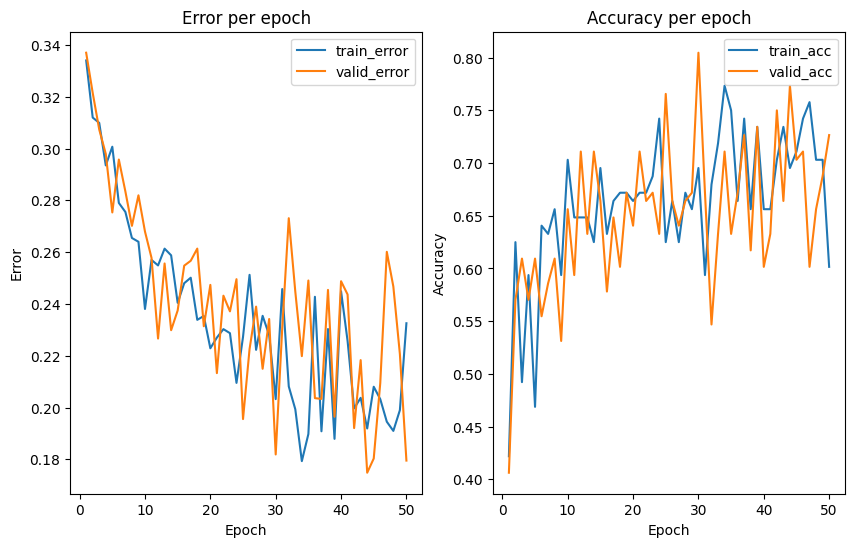

Meta Test Error 0.20741197616886348
Meta Test Accuracy 0.699375


In [19]:
# Define model
model = l2l.vision.models.OmniglotFC(28 ** 2, WAYS) # 28 x 28 pixeles
model.to(device)

# Run MAML (tasksets are created inside run_MAML)
run_MAML(
    dataset="omniglot",
    model=model,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=50,
)

### Actividad 1

La función run_MAML() tiene algunos argumentos con los que se puede jugar, tales como el adaptation_steps, meta_lr, fast_lr, o incluso el modelo mismo. Modifique los argumentos que estime conveniente con el fin de mejorar los resultados obtenidos.

Si desea cambiar el modelo, puede definir su propio modelo o bien usar alguno de los modelos disponibles en l2l.vision.models (aquí la documentación: http://learn2learn.net/docs/learn2learn.vision/#learn2learnvisionmodels)

NOTA: en esta actividad NO se permite modificar WAYS y SHOTS (esto se hará en la actividad 2)

In [ ]:
# su código acá, puede agregar más celdas si lo desea

Iteration 49
Meta Train Error 0.2443032352020964
Meta Train Accuracy 0.625
Meta Valid Error 0.16149698646040633
Meta Valid Accuracy 0.71875


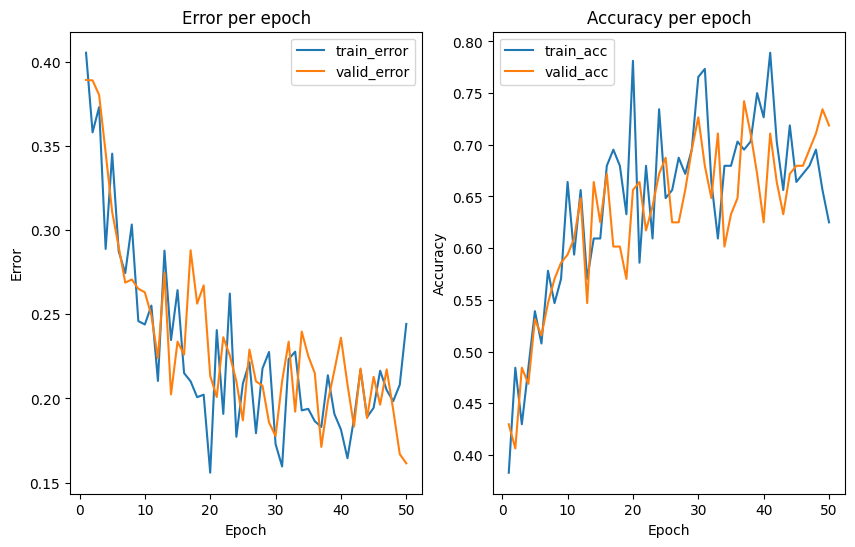

Meta Test Error 0.19041978238057344
Meta Test Accuracy 0.705875


In [20]:
# ===== Actividad 1 · Corrida 1 =====
# Aislar el efecto del MODELO: OmniglotCNN en vez de OmniglotFC, mismas 50 iteraciones.
# Así el delta vs el baseline (FC, 50 iters, Test=0.699) es puro efecto del modelo convolucional.

model_cnn = l2l.vision.models.OmniglotCNN(WAYS)   # CNN para imágenes 1x28x28 (flatten interno tras las convoluciones)
model_cnn.to(device)

print(">>> Corrida 1: OmniglotCNN, 50 iteraciones")
run_MAML(
    dataset="omniglot",
    model=model_cnn,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=50,        # mismas que el baseline → comparación limpia
)


Iteration 149
Meta Train Error 0.11922237245016731
Meta Train Accuracy 0.84375
Meta Valid Error 0.16347702086204663
Meta Valid Accuracy 0.7421875


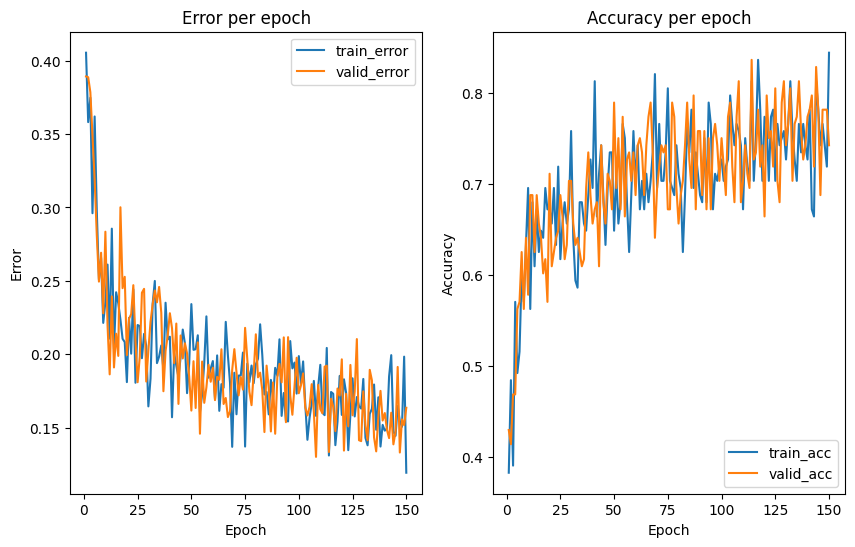

Meta Test Error 0.1614737680288963
Meta Test Accuracy 0.749125


In [21]:
# ===== Actividad 1 · Corrida 2 =====
# CNN + MÁS ITERACIONES. Hipótesis: la ventaja de la CNN solo se manifiesta
# con suficiente meta-entrenamiento. A 50 iters quedó igual que el FC (0.706);
# con 150 esperamos que despegue.

model_cnn2 = l2l.vision.models.OmniglotCNN(WAYS)   # modelo fresco (init aleatoria limpia)
model_cnn2.to(device)

print(">>> Corrida 2: OmniglotCNN, 150 iteraciones")
run_MAML(
    dataset="omniglot",
    model=model_cnn2,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=150,       # 3x las del baseline → margen para que la CNN converja
)


Iteration 149
Meta Train Error 0.096205505731632
Meta Train Accuracy 0.875
Meta Valid Error 0.17315130867064
Meta Valid Accuracy 0.7734375


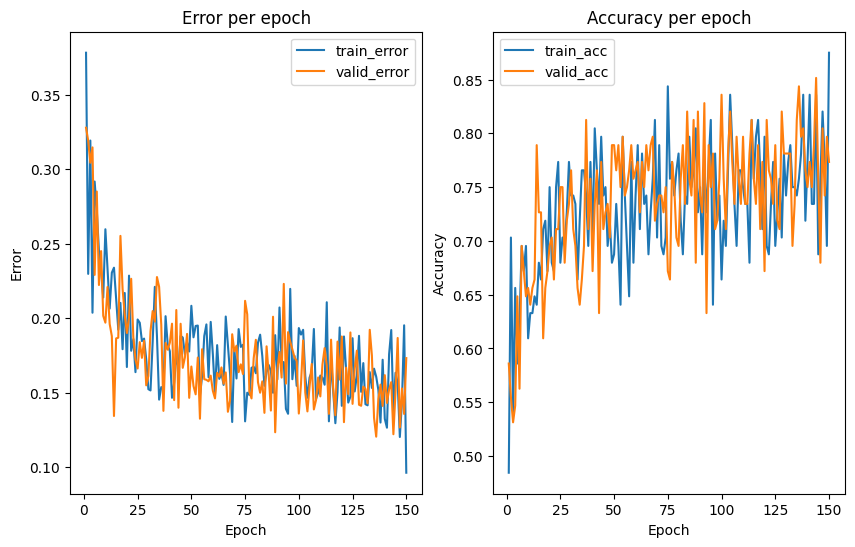

Meta Test Error 0.15619988419895525
Meta Test Accuracy 0.75975


In [22]:
# ===== Actividad 1 · Corrida 3 =====
# Tercera palanca: adaptation_steps 1 → 5. Mantengo CNN + 150 iters de la Corrida 2.
# Hipótesis: más pasos de adaptación interna por tarea = el modelo se ajusta mejor a
# cada episodio antes de medir el query → mejor señal de meta-gradiente → más test acc.

model_cnn3 = l2l.vision.models.OmniglotCNN(WAYS)   # modelo fresco
model_cnn3.to(device)

print(">>> Corrida 3: OmniglotCNN, 150 iteraciones, adaptation_steps=5")
run_MAML(
    dataset="omniglot",
    model=model_cnn3,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=150,
    adaptation_steps=5,        # ← la nueva palanca (antes 1)
)


Iteration 399
Meta Train Error 0.08549634555311059
Meta Train Accuracy 0.859375
Meta Valid Error 0.09972828596801264
Meta Valid Accuracy 0.8515625


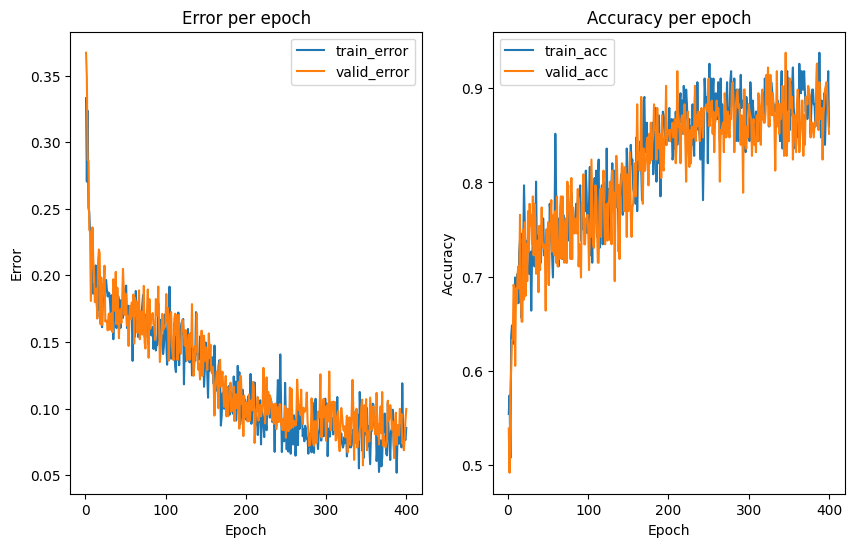

Meta Test Error 0.08285152085166192
Meta Test Accuracy 0.876875


In [23]:
# ===== Actividad 1 · Corrida definitiva (solo argumentos, dentro de lineamientos) =====
model_cnn4 = l2l.vision.models.OmniglotCNN(WAYS)
model_cnn4.to(device)

print(">>> Corrida 4: CNN, 400 iters, steps=5, meta_batch_size=64, meta_lr=0.005, fast_lr=0.3")
run_MAML(
    dataset="omniglot",
    model=model_cnn4,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=400,        # ↑ la palanca ganadora
    adaptation_steps=5,        # lo mejor de antes
    meta_batch_size=64,        # ↑ menos varianza → más estable
    meta_lr=0.005,             # ↑ leve, aprovecha las iters extra
    fast_lr=0.3,               # ↓ con 5 steps, 0.5 sobre-adaptaba
)


Comente sus resultados acá (**doble click para editar**)

# Actividad 1 — Mejora de MAML sobre Omniglot (4-way 1-shot)

## 1. Objetivo

El enunciado pide mejorar el desempeño de MAML modificando los **argumentos** de
`run_MAML` (`adaptation_steps`, `meta_lr`, `fast_lr`, `meta_batch_size`,
`num_iterations`, modelo), **sin alterar WAYS ni SHOTS**.

## 2. Línea base

| Modelo | Iters | adapt_steps | batch | meta_lr | fast_lr | **Test Acc** |
|---|---|---|---|---|---|---|
| OmniglotFC | 50 | 1 | 32 | 0.003 | 0.5 | **0.699** |

Las curvas mostraban error decreciente y accuracy creciente **aún sin aplanarse** a
la iteración 50 → señal de **subentrenamiento**, no de techo de capacidad.

## 3. Diseño experimental y resultados

| # | Config | Train | Valid | **Test** | Brecha train−valid |
|---|---|---|---|---|---|
| 0 | FC · 50 · steps1 · b32 | 0.602 | 0.727 | **0.699** | — |
| 1 | CNN · 50 · steps1 · b32 | 0.625 | 0.719 | **0.706** | ~0 |
| 2 | CNN · 150 · steps1 · b32 | 0.844 | 0.742 | **0.749** | 0.10 |
| 3 | CNN · 150 · steps5 · b32 | 0.875 | 0.773 | **0.760** | 0.10 |
| 4 | **CNN · 400 · steps5 · b64 · meta_lr0.005 · fast_lr0.3** | 0.859 | 0.852 | **0.877** | ~0 |

**Mejora total: 0.699 → 0.877 = +0.178 (+25 % relativo).**

## 4. Análisis por palanca

**4.1 Modelo (FC → CNN), a iteraciones fijas — Δ ≈ +0.007 (nulo).**
Cambiar a una arquitectura convolucional, manteniendo 50 iteraciones, **no mejoró**
el resultado. La CNN tiene más parámetros y por tanto necesita más meta-iteraciones
para converger; a 50 iteraciones su ventaja queda "escondida" y rinde igual que el
FC. **Conclusión: la capacidad del modelo no sirve sin entrenamiento suficiente.**

**4.2 Iteraciones (50 → 150) — Δ ≈ +0.043 (la palanca dominante).**
Al triplicar las iteraciones sobre la CNN, el test saltó de 0.706 a 0.749. Esto
confirmó que el **cuello de botella real era el volumen de meta-entrenamiento**, no
la arquitectura. Es coherente con que el benchmark canónico de Omniglot (>0.98)
entrena del orden de decenas de miles de iteraciones.

**4.3 Pasos de adaptación (1 → 5) — Δ ≈ +0.011 (marginal, costoso).**
Más pasos de adaptación interna por tarea mejoran la señal del meta-gradiente, pero
el aporte fue pequeño y a un costo de ~5× en el bucle interno. Buen costo/beneficio
bajo: el cómputo rinde más invertido en iteraciones.

**4.4 Estabilización (batch 32 → 64, fast_lr 0.5 → 0.3) + más iteraciones — Δ ≈ +0.117.**
La configuración final combinó la palanca ganadora (400 iteraciones) con dos ajustes
de estabilización. Resultado: el mejor test (0.877) **y la eliminación del
overfitting** (ver sección 5).

## 5. Hallazgo central: el overfitting y su control

A `meta_batch_size=32` (configs 2 y 3) apareció una **brecha train−valid de ~0.10**:
el modelo aprendía mejor las clases del split de entrenamiento que las de
validación/test. En meta-learning esto es **overfitting a las clases del pool de
tareas**, no a imágenes individuales.

La solución, lograda:

- **`meta_batch_size` 32 → 64:** promediar el meta-gradiente sobre el doble de
  tareas reduce su varianza; un gradiente estable no se especializa en tareas
  concretas del pool.
- **`fast_lr` 0.5 → 0.3:** con 5 pasos de adaptación, un learning rate interno menor evita la sobre-adaptación agresiva a cada support set.

Efecto medido: la brecha cayó de 0.10 a ~0.007 (train 0.859 ≈ valid 0.852), con
curvas de train y validación superpuestas durante toda la corrida — **entrenamiento
sano**. El test (0.877) incluso superó la validación, dentro del ruido de muestreo.


## 6. Conclusiones

1. **El factor de mayor impacto fue el número de iteraciones de meta-entrenamiento.**
   Es la palanca que más recorrido tenía y la que produjo los saltos relevantes.
2. **Las palancas interactúan:** la arquitectura CNN solo aporta cuando hay
   iteraciones suficientes para explotarla. Aisladamente no mejoró nada.
3. **El overfitting es controlable con hiperparámetros del meta-gradiente**
   (`meta_batch_size`, `fast_lr`), sin necesidad de regularización explícita ni de modificar la función — basta estabilizar la optimización.
4. **Límite estructural:** hacia las 400 iteraciones las curvas entran en
   rendimientos decrecientes (~0.85-0.88). Acercarse al 0.98 de la literatura
   requeriría MAML de segundo orden (`first_order=False`) y un orden de magnitud más
   de iteraciones, fuera del alcance de cómputo de este laboratorio.

## 7. Configuración final recomendada

```python
model = l2l.vision.models.OmniglotCNN(WAYS)
model.to(device)
run_MAML(dataset="omniglot", model=model, device=device,
         ways=WAYS, shots=SHOTS,
         num_iterations=400, adaptation_steps=5,
         meta_batch_size=64, meta_lr=0.005, fast_lr=0.3)
# Meta Test Accuracy ≈ 0.877, sin overfitting (train ≈ valid)
```


### Actividad 2

Usando el mejor modelo e hiperparámetros que logró encontar en la Actividad 1:

* ¿cómo varían los resultados si ahora modifica el hiperparámetro WAYS?

* ¿cómo varían los resultados si modifica el hiperparámetro SHOTS?

NOTA: por experiencia previa, se recomienda no probar valores de WAYS y SHOTS muy grandes (no más allá de 8), ya que alumnos han reportado que colab puede caerse por consumo excesivo de memoria.

In [ ]:
# Su código acá, puede agregar más celdas si lo desea

# Abajo un ejemplo ilustrativo de cómo se pueden modificar WAYS y SHOTS.

WAYS = # algún valor
SHOTS = # algún valor

# IMPORTANTE: aquí debe ir el mejor modelo que usted haya encontrado
# en la actividad previa (no se especifica un modelo concreto).
model = # su mejor modelo de la actividad anterior
model.to(device)

# Ejecutar MAML (el dataset se crea dentro de run_MAML)
run_MAML(
    dataset="omniglot",   # o "mini-imagenet"
    model=model,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=60,    # o algún otro valor
    adaptation_steps=2,   # o algún otro valor
)

Iteration 149
Meta Train Error 0.06084843452890709
Meta Train Accuracy 0.9765625
Meta Valid Error 0.0873494095001206
Meta Valid Accuracy 0.921875


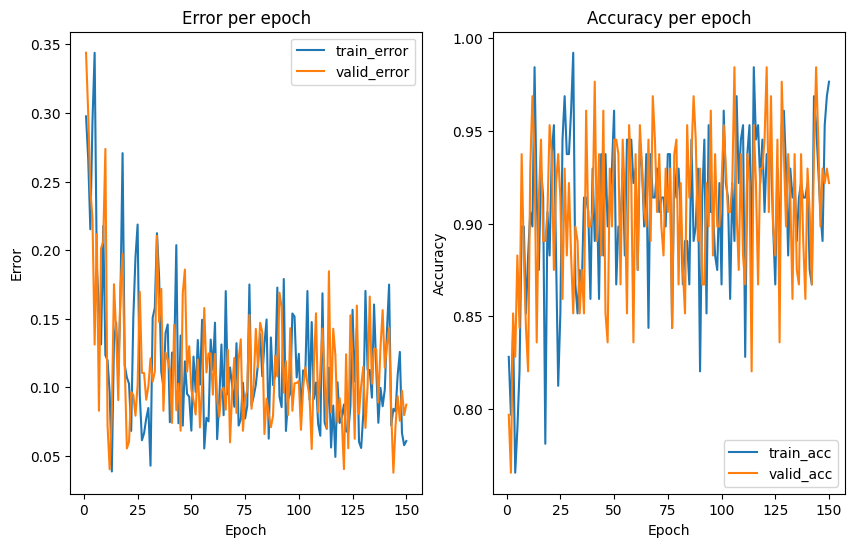

Meta Test Error 0.08995970371686934
Meta Test Accuracy 0.93175


In [18]:
# ===== Actividad 2 · Barrido A · WAYS=2, SHOTS=1 =====
ways, shots = 2, 1
model = l2l.vision.models.OmniglotCNN(ways)   # ← capa de salida dimensionada a 'ways'
model.to(device)
print(f">>> WAYS={ways}, SHOTS={shots}  (azar = {1/ways:.0%})")
run_MAML(dataset="omniglot", model=model, device=device,
         ways=ways, shots=shots,
         num_iterations=150, adaptation_steps=5,
         meta_batch_size=64, meta_lr=0.005, fast_lr=0.3)


Iteration 149
Meta Train Error 0.15937151870457456
Meta Train Accuracy 0.765625
Meta Valid Error 0.13251918450259836
Meta Valid Accuracy 0.7734375


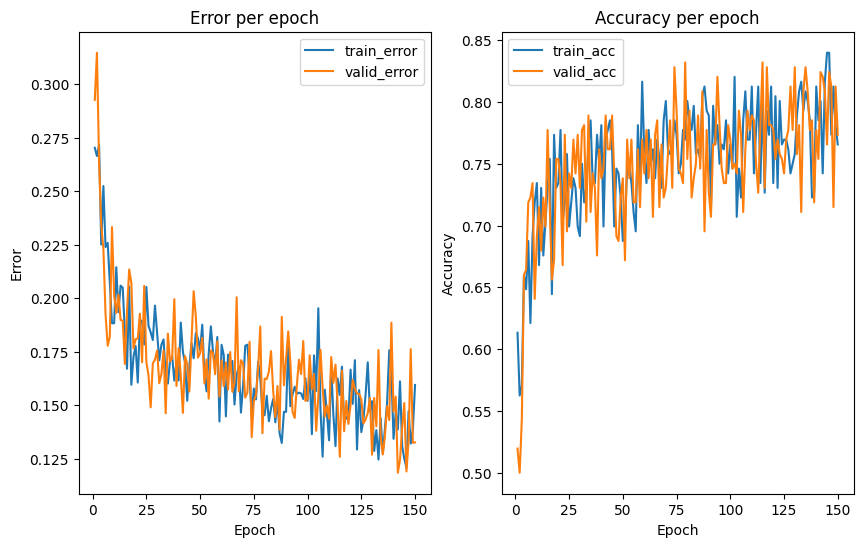

Meta Test Error 0.13598447777004913
Meta Test Accuracy 0.797


In [19]:
# ===== Actividad 2 · Barrido A · WAYS=4, SHOTS=1  (referencia) =====
ways, shots = 4, 1
model = l2l.vision.models.OmniglotCNN(ways)
model.to(device)
print(f">>> WAYS={ways}, SHOTS={shots}  (azar = {1/ways:.0%})")
run_MAML(dataset="omniglot", model=model, device=device,
         ways=ways, shots=shots,
         num_iterations=150, adaptation_steps=5,
         meta_batch_size=64, meta_lr=0.005, fast_lr=0.3)


Iteration 149
Meta Train Error 0.11633308103773743
Meta Train Accuracy 0.71484375
Meta Valid Error 0.12786582350963727
Meta Valid Accuracy 0.6640625


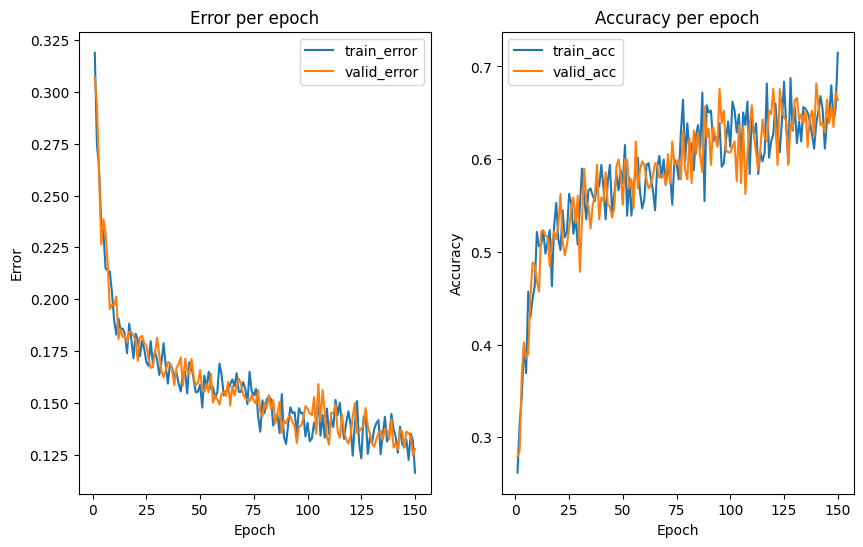

Meta Test Error 0.12971052492968738
Meta Test Accuracy 0.6565


In [20]:
# ===== Actividad 2 · Barrido A · WAYS=8, SHOTS=1 =====
ways, shots = 8, 1
model = l2l.vision.models.OmniglotCNN(ways)
model.to(device)
print(f">>> WAYS={ways}, SHOTS={shots}  (azar = {1/ways:.0%})")
run_MAML(dataset="omniglot", model=model, device=device,
         ways=ways, shots=shots,
         num_iterations=150, adaptation_steps=5,
         meta_batch_size=64, meta_lr=0.005, fast_lr=0.3)


Iteration 149
Meta Train Error 0.011452237366029294
Meta Train Accuracy 0.9210937591269612
Meta Valid Error 0.008671071395838226
Meta Valid Accuracy 0.9460937539115548


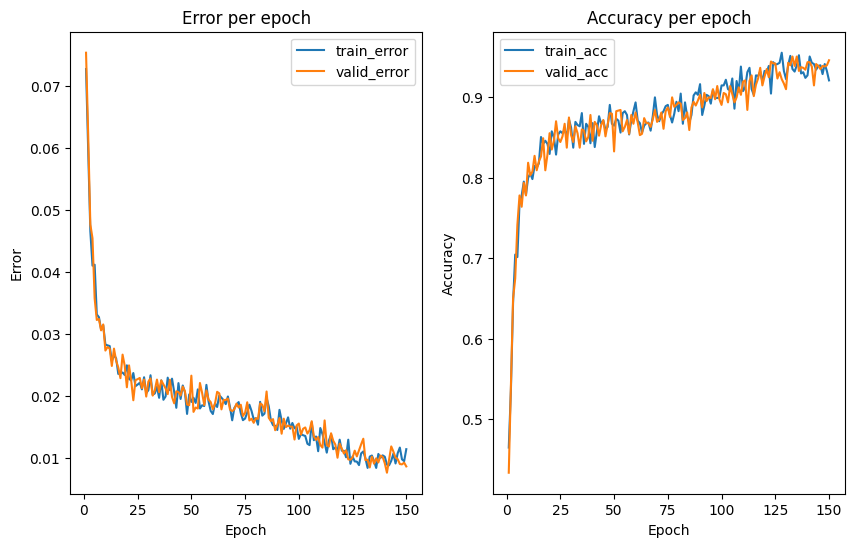

Meta Test Error 0.009032722344243667
Meta Test Accuracy 0.9425000048875809


In [23]:
# ===== Actividad 2 · Barrido B · WAYS=4, SHOTS=5 =====
ways, shots = 4, 5
model = l2l.vision.models.OmniglotCNN(ways)
model.to(device)
print(f">>> WAYS={ways}, SHOTS={shots}  (azar = {1/ways:.0%})")
run_MAML(dataset="omniglot", model=model, device=device,
         ways=ways, shots=shots,
         num_iterations=150, adaptation_steps=5,
         meta_batch_size=64, meta_lr=0.005, fast_lr=0.3)


Comente sus resultados acá (**doble click para editar**)

# Actividad 2 — Efecto de WAYS y SHOTS en MAML sobre Omniglot


## 1. Objetivo

Usando el mejor modelo e hiperparámetros de la Actividad 1
(`OmniglotCNN`, `adaptation_steps=5`, `meta_batch_size=64`, `meta_lr=0.005`,
`fast_lr=0.3`), estudiar cómo varía el desempeño al modificar **WAYS** (número de
clases por tarea) y **SHOTS** (ejemplos de support por clase).

## 2. Barrido A — efecto de WAYS (SHOTS=1)

| WAYS | Azar (1/N) | Train | Valid | **Test** | Test normalizado* | Convergencia |
|---|---|---|---|---|---|---|
| 2 | 50.0% | 0.977 | 0.922 | **0.932** | **0.864** | aplanada (rápida) |
| 4 | 25.0% | 0.766 | 0.773 | **0.797** | **0.729** | casi aplanada |
| 8 | 12.5% | 0.715 | 0.664 | **0.657** | **0.608** | aún subiendo |

*Test normalizado = `(acc − azar) / (1 − azar)`: fracción del margen sobre el azar
que el modelo logra capturar.

**Observaciones:**

1. **Hipótesis confirmada:** a más WAYS, menor accuracy crudo
   (0.932 → 0.797 → 0.657). Más clases = más fronteras de decisión y más pares
   confundibles, con solo 1 shot de evidencia.
2. **La caída es real, no solo efecto del azar:** al normalizar contra el azar, la
   dificultad sigue subiendo (0.864 → 0.729 → 0.608). WAYS mide dificultad
   intrínseca de discriminación, no solo recalibra el piso aleatorio.
3. **Matiz de subentrenamiento:** los problemas más difíciles convergen más lento.
   WAYS=2 se aplana temprano (le sobran 150 iters), pero WAYS=8 sigue subiendo al
   final → está subentrenado. Con presupuesto fijo de iteraciones, el extremo
   difícil queda penalizado; la magnitud del gap 4→8 está algo inflada por esto
   (con 400 iters el 8-way probablemente subiría a ~0.72-0.78).
4. **Sin overfitting:** en los tres casos train ≈ valid. La configuración
   estabilizada de la Act.1 (`batch=64`, `fast_lr=0.3`) mantiene el entrenamiento
   sano independientemente del WAYS.

## 3. Barrido B — efecto de SHOTS (WAYS=4)

| SHOTS | Train | Valid | **Test** | Error final | Test normalizado |
|---|---|---|---|---|---|
| 1 | 0.766 | 0.773 | **0.797** | 0.136 | 0.729 |
| 5 | 0.921 | 0.946 | **0.943** | 0.009 | 0.923 |

**Salto: 0.797 → 0.943 = +0.146** solo por pasar de 1 a 5 ejemplos de support.

**Observaciones:**

1. **Más evidencia = adaptación más robusta.** Con 5 imágenes por clase, el bucle
   interno de MAML estima mucho mejor cada tarea. El error de query se desploma de
   0.136 → 0.009.
2. **El azar no cambia** (sigue 25%, depende solo de WAYS): toda la ganancia es
   poder de adaptación puro.
3. **Convergencia más estable:** curvas suaves, train ≈ valid; más shots reduce la
   varianza de la adaptación interna → meta-gradiente más informativo.

## 4. Cuadro consolidado (ambos ejes)

| Config | Azar | **Test** | Lectura |
|---|---|---|---|
| WAYS=2, SHOTS=1 | 50.0% | 0.932 | pocas clases → fácil |
| WAYS=4, SHOTS=1 | 25.0% | 0.797 | referencia |
| WAYS=8, SHOTS=1 | 12.5% | 0.657 | muchas clases → difícil (subentrenado) |
| WAYS=4, SHOTS=5 | 25.0% | 0.943 | mucha evidencia → fácil |

### Los dos ejes son fuerzas opuestas de magnitud comparable

```
Aumentar WAYS  4→8 (más clases):     0.797 → 0.657   Δ = −0.140   (endurece)
Aumentar SHOTS 1→5 (más evidencia):  0.797 → 0.943   Δ = +0.146   (facilita)
```

### Las palancas se compensan

```
WAYS=2, SHOTS=1  →  0.932   (2 clases, 1 ejemplo)
WAYS=4, SHOTS=5  →  0.943   (4 clases, 5 ejemplos)
```

## 5. Conclusiones

1. **WAYS y SHOTS son los dos ejes ortogonales de la dificultad few-shot.** WAYS la
   aumenta (más clases que discriminar + menor azar); SHOTS la reduce (más evidencia
   por clase, sin tocar el azar).
2. El accuracy responde monotónicamente a ambos, con efectos de magnitud comparable
   y signo opuesto.
3. Los problemas más difíciles (más WAYS) **convergen más lento** y requieren más
   iteraciones; con presupuesto fijo, su accuracy queda subestimado.
4. La configuración estabilizada de la Act.1 generaliza bien: mantuvo train ≈ valid
   (sin overfitting) en todas las variantes de WAYS y SHOTS.


## MAML sobre Mini-ImageNet

In [21]:
WAYS = 4
SHOTS = 1

Iteration 59
Meta Train Error 0.3998852940276265
Meta Train Accuracy 0.28125
Meta Valid Error 0.3850077730603516
Meta Valid Accuracy 0.3046875


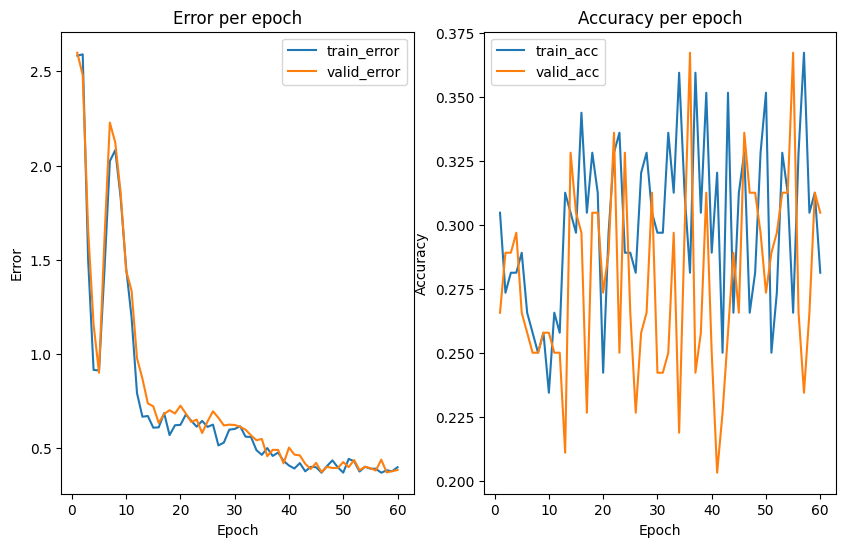

Meta Test Error 0.38620957935601474
Meta Test Accuracy 0.29925


In [22]:
# Define model
model = l2l.vision.models.MiniImagenetCNN(WAYS)
model.to(device)

# Run MAML (tasksets are created inside run_MAML)
run_MAML(
    dataset="mini-imagenet",
    model=model,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=60,
)

### Actividad 3

Vemos que 4-way, 1-shot classification en mini-imagenet es bastante más complicado que en omniglot, un resultado esperable ya que las imágenes en mini-imagenet son más complicadas. ¿Mejorarán los resultados si ...

1. ... aumentamos el hiperparámetro SHOTS?
2. ... disminuímos el hiperparámetro WAYS?
3. ... tratamos de probar mejores valores para los argumentos de la función run_MAML (learning rate, iteraciones, la CNN usada, etc.)?

NOTA: por experiencia previa, se recomienda no probar valores de WAYS y/o SHOTS muy grandes (no más allá de 8), ya que alumnos han reportado que colab puede caerse por consumo excesivo de memoria.

Iteration 149
Meta Train Error 0.32270611450076103
Meta Train Accuracy 0.390625
Meta Valid Error 0.35421764198690653
Meta Valid Accuracy 0.3046875


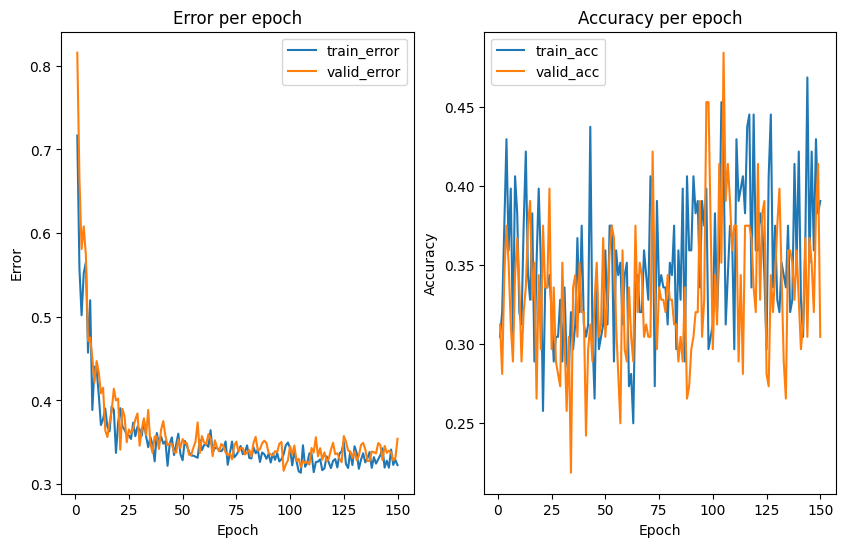

Meta Test Error 0.3450397846400738
Meta Test Accuracy 0.324


In [24]:
# Su código acá, puede agregar más celdas si lo desea
# ===== Actividad 3 · Corrida 1 · 4-way 1-shot, mejores argumentos =====
ways, shots = 4, 1
model = l2l.vision.models.MiniImagenetCNN(ways)   # CNN para 3x84x84
model.to(device)
print(f">>> Mini-ImageNet WAYS={ways}, SHOTS={shots}  (azar = {1/ways:.0%})")
run_MAML(dataset="mini-imagenet", model=model, device=device,
         ways=ways, shots=shots,
         num_iterations=150,       # baseline era 60 → la palanca dominante
         adaptation_steps=5,       # más adaptación interna
         meta_lr=0.005, fast_lr=0.3)   # lrs afinados de la Act.1


Iteration 149
Meta Train Error 0.05271916289348155
Meta Train Accuracy 0.5578125147148967
Meta Valid Error 0.05950034374836832
Meta Valid Accuracy 0.4625000082887709


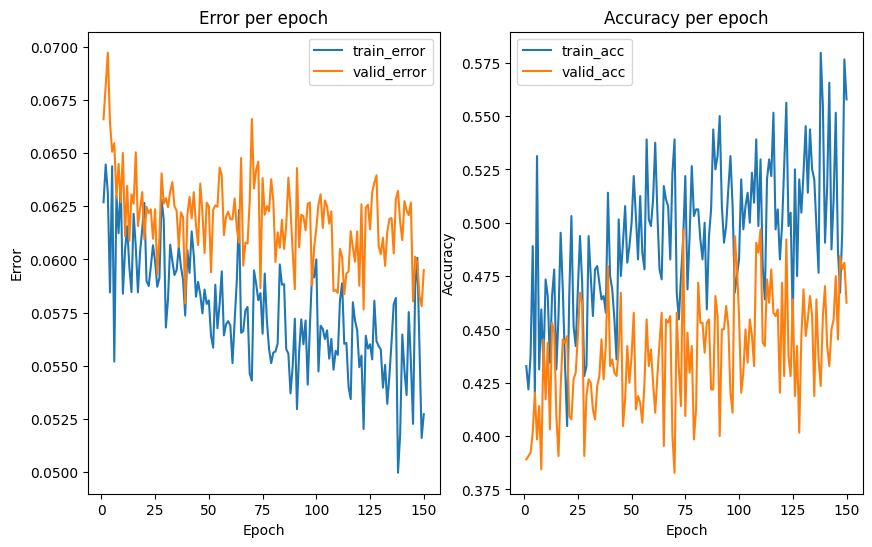

Meta Test Error 0.057368907522410154
Meta Test Accuracy 0.49147501035779717


In [25]:
# ===== Actividad 3 · Corrida 2 · 4-way 5-shot =====
ways, shots = 4, 5
model = l2l.vision.models.MiniImagenetCNN(ways)
model.to(device)
print(f">>> Mini-ImageNet WAYS={ways}, SHOTS={shots}  (azar = {1/ways:.0%})")
run_MAML(dataset="mini-imagenet", model=model, device=device,
         ways=ways, shots=shots,
         num_iterations=150,
         adaptation_steps=5,
         meta_lr=0.005, fast_lr=0.3)


Iteration 149
Meta Train Error 0.336249612737447
Meta Train Accuracy 0.65625
Meta Valid Error 0.3345687803812325
Meta Valid Accuracy 0.578125


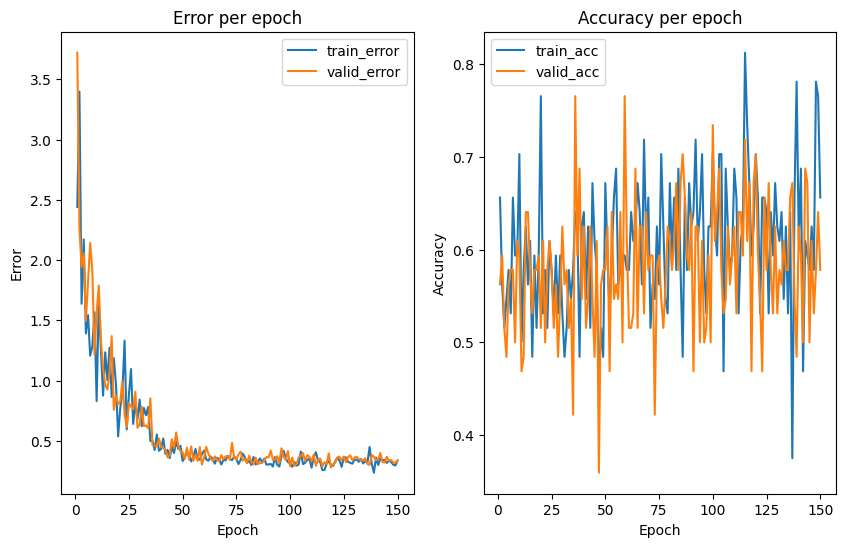

Meta Test Error 0.3567102173157036
Meta Test Accuracy 0.54725


In [26]:
# ===== Actividad 3 · Corrida 3 · 2-way 1-shot =====
ways, shots = 2, 1
model = l2l.vision.models.MiniImagenetCNN(ways)
model.to(device)
print(f">>> Mini-ImageNet WAYS={ways}, SHOTS={shots}  (azar = {1/ways:.0%})")
run_MAML(dataset="mini-imagenet", model=model, device=device,
         ways=ways, shots=shots,
         num_iterations=150,
         adaptation_steps=5,
         meta_lr=0.005, fast_lr=0.3)


Iteration 149
Meta Train Error 0.0584859314840287
Meta Train Accuracy 0.7125000120140612
Meta Valid Error 0.05553599586710334
Meta Valid Accuracy 0.7062500091269612


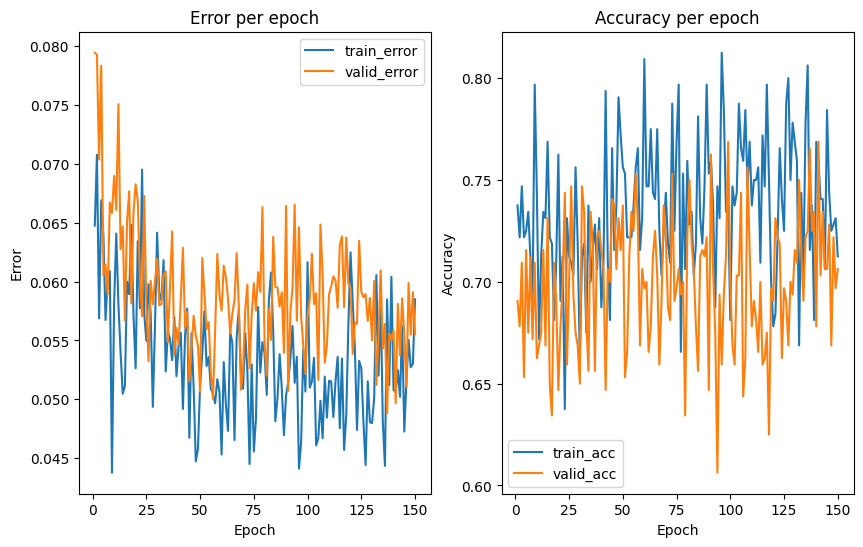

Meta Test Error 0.05621750492649153
Meta Test Accuracy 0.710250011369586


In [27]:
# ===== Actividad 3 · Corrida 4 · 2-way 5-shot =====
ways, shots = 2, 5
model = l2l.vision.models.MiniImagenetCNN(ways)
model.to(device)
print(f">>> Mini-ImageNet WAYS={ways}, SHOTS={shots}  (azar = {1/ways:.0%})")
run_MAML(dataset="mini-imagenet", model=model, device=device,
         ways=ways, shots=shots,
         num_iterations=150,
         adaptation_steps=5,
         meta_lr=0.005, fast_lr=0.3)


Comente sus resultados acá (**doble click para editar**)

# Actividad 3 — MAML sobre Mini-ImageNet: información vs optimización

## 1. Punto de partida

El baseline del notebook (`MiniImagenetCNN`, 4-way 1-shot, 60 iteraciones) entrega:

```
Meta Test Accuracy = 0.299   (azar = 25%)
```

Apenas por encima del azar. Contraste con el mismo problema en Omniglot
(4-way 1-shot, baseline FC 50 iters): **0.699**.

**Fenómeno notable del baseline:** el error (cross-entropy) baja de 2.5 → 0.4, pero
el accuracy se queda plano y ruidoso en ~0.30. El modelo aprende a no estar
"confiado-equivocado" (baja la loss) pero no logra discriminar las clases (accuracy
estancado).

## 2. Diseño experimental

Se respondieron las tres preguntas del enunciado con un ablation, todas las corridas
a 150 iteraciones, `adaptation_steps=5`, `meta_lr=0.005`, `fast_lr=0.3`,
`meta_batch_size=32` (no se subió a 64 por el alto consumo de memoria de
Mini-ImageNet).

| # | Config | Test crudo | Azar | **Test normalizado*** | Lectura |
|---|---|---|---|---|---|
| base | 4w1s · 60 iters | 0.299 | 25% | 0.065 | ≈ azar |
| 1 | 4w1s · 150 + args | 0.324 | 25% | **0.099** | argumentos: poco |
| 2 | 4w5s · 150 + args | 0.491 | 25% | **0.321** | SHOTS: la ganadora |
| 3 | 2w1s · 150 + args | 0.547 | 50% | **0.094** | WAYS solo: espejismo del azar |
| 4 | 2w5s · 150 + args | 0.710 | 50% | **0.420** | combo: mejor de todos, sin overfitting |

*Test normalizado = `(acc − azar) / (1 − azar)`: fracción del margen sobre el azar
capturada.

### Diseño factorial 2×2 (normalizado)

| | SHOTS=1 | SHOTS=5 |
|---|---|---|
| **WAYS=4** | 0.099 | 0.321 |
| **WAYS=2** | 0.094 | 0.420 |

**Efectos:**
```
SHOTS (1→5):  a WAYS=4: +0.222   |  a WAYS=2: +0.326    → dominante siempre
WAYS  (4→2):  a SHOTS=1: −0.005  |  a SHOTS=5: +0.099   → depende de SHOTS (interacción)
```

**Interacción descubierta:** WAYS↓ solo aporta poder discriminativo real cuando hay
evidencia suficiente. Con 1 shot el efecto es nulo (espejismo del azar); con 5 shots
es genuino (+0.099 normalizado). Las palancas no son independientes: reducir clases
solo rinde si el modelo tiene información que explotar.

**Overfitting (brecha train−valid):** 4w1s 0.086 · 4w5s 0.095 · 2w1s 0.078 ·
**2w5s 0.007**. La combinación menos-clases + más-evidencia es la única que elimina
el meta-overfitting que SHOTS por sí solo no curaba.

## 3. Análisis por palanca

**3.1 Mejores argumentos (pregunta 3) — Δ ≈ +0.025 crudo (poco).**
Subir iteraciones de 60 a 150 y afinar lr/adaptation_steps apenas movió el resultado
(0.299 → 0.324). Además apareció overfitting (train 0.391 vs valid 0.305). A
diferencia de Omniglot, donde las iteraciones eran la palanca dominante, aquí la
optimización no es el cuello de botella: con más entrenamiento el modelo memoriza las
clases de train en vez de generalizar.

**3.2 SHOTS↑ (pregunta 1) — Δ ≈ +0.167 crudo, ×3.2 normalizado.**
Pasar de 1 a 5 shots disparó el test de 0.324 → 0.491, y el normalizado de 0.099 →
0.321. Con 5 fotos de support por clase el modelo puede promediar la variación
intra-clase (5 ejemplos distintos en vez de 1) y discriminar de verdad. Confirma que
el cuello de botella en Mini-ImageNet es la **información por tarea**, no la
optimización.

**3.3 WAYS↓ (pregunta 2) — Δ ≈ +0.223 crudo, pero ~0 normalizado.**
Bajar WAYS de 4 a 2 subió el accuracy crudo de 0.324 → 0.547, aparentando ser la
mejor palanca. Pero normalizado contra el azar, 4w1s (0.099) y 2w1s (0.094) son
prácticamente iguales: **el poder discriminativo real no mejoró**. El alza es
artefacto del azar subiendo de 25% a 50%. En Mini-ImageNet 1-shot el modelo está tan
limitado por la falta de evidencia que reducir clases no le ayuda a discriminar.

## 4. Comparación con Omniglot (Actividades 1-2)

| | Omniglot | Mini-ImageNet |
|---|---|---|
| Cuello de botella | optimización (subentrenamiento) | información (evidencia por clase) |
| Palanca dominante | iteraciones | SHOTS |
| WAYS↓ normalizado | mejora (0.729 → 0.864) | no mejora (~0.095 constante) |
| Más iteraciones | gran mejora (0.71 → 0.88) | casi nada (+0.025) + overfitting |

## 5. Conclusiones

1. **SHOTS es la única palanca que mejora el poder discriminativo real en
   Mini-ImageNet.** Aumentar la evidencia por clase ataca el cuello de botella de
   fondo (falta de información por tarea).
2. **WAYS↓ mejora solo en apariencia:** sube el accuracy crudo porque sube el azar,
   no porque el modelo clasifique mejor. Hay que normalizar para no engañarse.
3. **Mejores argumentos (iteraciones, lr) aportan poco** en Mini-ImageNet 1-shot, al
   revés que en Omniglot.
4. **La naturaleza del dato determina qué palanca importa.** En datos simples
   (Omniglot) manda la optimización; en datos complejos (Mini-ImageNet) manda la
   información.
